In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from credit_classification_pipeline.config import get_absolute_path, load_config

cfg = load_config("data.yaml")
raw = get_absolute_path(cfg["sources"]["give_me_some_credit"]["local_dir"])
train = pd.read_csv(raw / "cs-training.csv", index_col=0, dtype_backend="pyarrow")

target = "SeriousDlqin2yrs"

train.shape, train[target].mean(), train.isna().mean().sort_values(ascending=False)

((150000, 11),
 0.06684,
 MonthlyIncome                           0.198207
 NumberOfDependents                      0.026160
 SeriousDlqin2yrs                        0.000000
 RevolvingUtilizationOfUnsecuredLines    0.000000
 age                                     0.000000
 NumberOfTime30-59DaysPastDueNotWorse    0.000000
 DebtRatio                               0.000000
 NumberOfOpenCreditLinesAndLoans         0.000000
 NumberOfTimes90DaysLate                 0.000000
 NumberRealEstateLoansOrLines            0.000000
 NumberOfTime60-89DaysPastDueNotWorse    0.000000
 dtype: float64)

In [11]:
train.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120,13,0,6,0,2
2,0,0.957151,40,0,0.121876,2600,4,0,0,0,1
3,0,0.65818,38,1,0.085113,3042,2,1,0,0,0
4,0,0.23381,30,0,0.03605,3300,5,0,0,0,0
5,0,0.907239,49,1,0.024926,63588,7,0,1,0,0
6,0,0.213179,74,0,0.375607,3500,3,0,1,0,1
7,0,0.305682,57,0,5710.0,<NA>,8,0,3,0,0
8,0,0.754464,39,0,0.20994,3500,8,0,0,0,0
9,0,0.116951,27,0,46.0,<NA>,2,0,0,0,<NA>
10,0,0.189169,57,0,0.606291,23684,9,0,4,0,2


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype          
---  ------                                --------------   -----          
 0   SeriousDlqin2yrs                      150000 non-null  int64[pyarrow] 
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  double[pyarrow]
 2   age                                   150000 non-null  int64[pyarrow] 
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64[pyarrow] 
 4   DebtRatio                             150000 non-null  double[pyarrow]
 5   MonthlyIncome                         120269 non-null  int64[pyarrow] 
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64[pyarrow] 
 7   NumberOfTimes90DaysLate               150000 non-null  int64[pyarrow] 
 8   NumberRealEstateLoansOrLines          150000 non-null  int64[pyarrow] 
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null

In [5]:
train.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.0,150000.0,150000.0,150000.0,150000.0,120269.0,150000.0,150000.0,150000.0,150000.0,146076.0
mean,0.06684,6.048438,52.295207,0.421033,353.005076,6670.221237,8.45276,0.265973,1.01824,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,14384.674215,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.029867,41.0,0.0,0.175074,3400.0,5.0,0.0,0.0,0.0,0.0
50%,0.0,0.154181,52.0,0.0,0.366508,5400.0,8.0,0.0,1.0,0.0,0.0
75%,0.0,0.559046,63.0,0.0,0.868254,8249.0,11.0,0.0,2.0,0.0,1.0
max,1.0,50708.0,109.0,98.0,329664.0,3008750.0,58.0,98.0,54.0,98.0,20.0


## Duplicates

In [6]:
train.duplicated().sum()

np.int64(609)

## Constant Cols

In [20]:
# unique count per column (NaN does not count as a value in nunique by default)
nunique = train.nunique(dropna=True)
constant_cols = nunique[nunique <= 1]
constant_cols

Series([], dtype: int64)

## Missing

In [31]:
## Missing Strategy

missing_cols = train.columns[train.isna().any()].tolist()

# create a dataframe with only the missing columns and the target

missing_data = (
    train.loc[:, missing_cols + [target]]
    .copy()
    .assign(
        **{
            f"{c}_missing": lambda d, c=c: d[c].isna().astype("int8")
            for c in missing_cols
        }
    )
)

missing_data

,MonthlyIncome,NumberOfDependents,SeriousDlqin2yrs,MonthlyIncome_missing,NumberOfDependents_missing
1,9120,2,1,0,0
2,2600,1,0,0,0
3,3042,0,0,0,0
4,3300,0,0,0,0
5,63588,0,0,0,0
...,...,...,...,...,...
149996,2100,0,0,0,0
149997,5584,2,0,0,0
149998,<NA>,0,0,1,0
149999,5716,0,0,0,0


In [32]:
(
    missing_data
    .groupby("MonthlyIncome_missing", observed=True)[target]
    .agg(default_rate="mean", n="size")
)

,default_rate,n
MonthlyIncome_missing,,
0,0.069486,120269
1,0.056137,29731


In [33]:
(
    missing_data
    .groupby("NumberOfDependents_missing", observed=True)[target]
    .agg(default_rate="mean", n="size")
)


,default_rate,n
NumberOfDependents_missing,,
0,0.06741,146076
1,0.045617,3924


### Analysis 

*MonthlyIncome  missing comparission for RevolvingUtilizationOfUnsecuredLines and Debt ratio

In [38]:
monthlyicnome_data = (
    train.loc[:, ["MonthlyIncome", "RevolvingUtilizationOfUnsecuredLines", "DebtRatio", target]]
    .copy()
    .assign(
        **{
            "MonthlyIncome_missing": lambda d: d["MonthlyIncome"].isna().astype("int8")
        }
    )
)

display(monthlyicnome_data.groupby("MonthlyIncome_missing")["RevolvingUtilizationOfUnsecuredLines"].agg(
    ["mean", "median", "std"]
))
display(monthlyicnome_data.groupby("MonthlyIncome_missing")["DebtRatio"].agg(["mean", "median", "std"]))


,mean,median,std
MonthlyIncome_missing,,,
0,5.899873,0.177282,257.040685
1,6.649421,0.081697,217.814854


,mean,median,std
MonthlyIncome_missing,,,
0,26.598777,0.296023,424.446457
1,1673.396556,1159.0,4248.372895


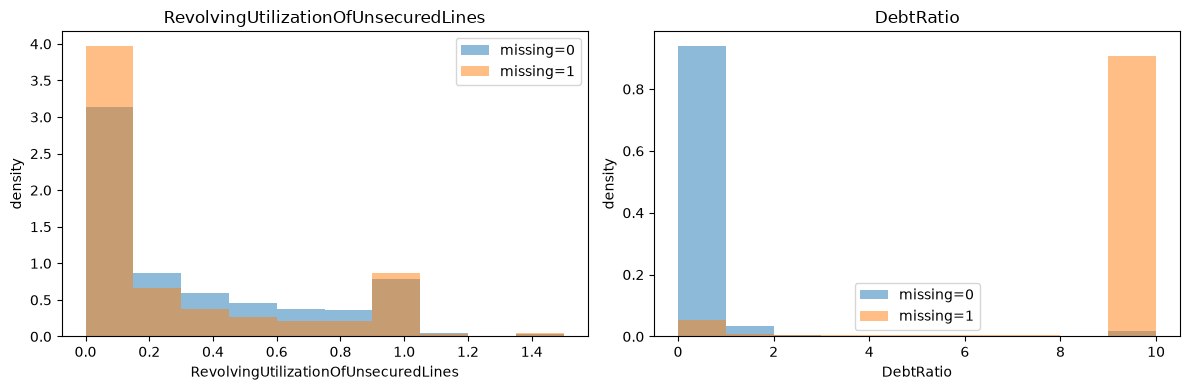

In [ ]:
import matplotlib.pyplot as plt
cols = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]
# clip to something sensible for the bulk of the data
clips = {
    "RevolvingUtilizationOfUnsecuredLines": 1.5,
    "DebtRatio": 10,
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, cols):
    for miss, g in monthlyicnome_data.groupby("MonthlyIncome_missing"):
        x = g[col].clip(upper=clips[col])
        ax.hist(x, bins=10, density=True, alpha=0.5, label=f"missing={miss}")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("density")
    ax.legend()
plt.tight_layout()

## Target

In [47]:
train[target].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: double[pyarrow]

In [49]:
missing_cols = train.columns[train.isna().any()].tolist()

eda = (
    train.copy()
    .assign(
        **{
            f"{c}_missing": lambda d, c=c: d[c].isna().astype("int8")
            for c in missing_cols
        }
    )
)

eda

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing
1,1,0.766127,45,2,0.802982,9120,13,0,6,0,2,0,0
2,0,0.957151,40,0,0.121876,2600,4,0,0,0,1,0,0
3,0,0.65818,38,1,0.085113,3042,2,1,0,0,0,0,0
4,0,0.23381,30,0,0.03605,3300,5,0,0,0,0,0,0
5,0,0.907239,49,1,0.024926,63588,7,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149996,0,0.040674,74,0,0.225131,2100,4,0,1,0,0,0,0
149997,0,0.299745,44,0,0.716562,5584,4,0,1,0,2,0,0
149998,0,0.246044,58,0,3870.0,<NA>,18,0,1,0,0,1,0
149999,0,0.0,30,0,0.0,5716,4,0,0,0,0,0,0


In [58]:
# DebtRatio 

# 1) overall tail
eda["DebtRatio"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
print("share >1:", (eda["DebtRatio"] > 1).mean(), "mean >1:", eda[eda["DebtRatio"] > 1]["DebtRatio"].mean())
print("share >100:", (eda["DebtRatio"] > 100).mean(), "mean >100:", eda[eda["DebtRatio"] > 100]["DebtRatio"].mean())

# 2) paired with income
print(eda.groupby("MonthlyIncome_missing")["DebtRatio"].describe(percentiles=[0.5, 0.9, 0.99]))

# 3) default rate by bins — income PRESENT only
has_income = eda["MonthlyIncome_missing"].eq(0)
tmp = eda.loc[has_income].copy()
tmp["debt_bin"] = pd.qcut(tmp["DebtRatio"], q=5, duplicates="drop")
(
    tmp.groupby("debt_bin", observed=True)[target]
    .agg(default_rate="mean", n=len)
)

share >1: 0.23424666666666666 mean >1: 1505.989566015513
share >100: 0.16253333333333334 mean >100: 2161.8776396088065
                          count         mean          std  min       50%  \
MonthlyIncome_missing                                                      
0                      120269.0    26.598777   424.446457  0.0  0.296023   
1                       29731.0  1673.396556  4248.372895  0.0    1159.0   

                            90%     99%       max  
MonthlyIncome_missing                              
0                      0.763149  661.82   61106.5  
1                        3785.0  8084.5  329664.0  


,default_rate,n
debt_bin,,
"(-0.001, 0.108]",0.059283,24054
"(0.108, 0.237]",0.061029,24054
"(0.237, 0.36]",0.053798,24053
"(0.36, 0.543]",0.070965,24054
"(0.543, 61106.5]",0.102353,24054


In [59]:
# Age

print(eda["age"].describe())
print("age<0:", (eda["age"] < 0).sum())
print("age==0:", (eda["age"] == 0).sum())
print("age<18:", (eda["age"] < 18).sum())
print("age>100:", (eda["age"] > 100).sum())

eda["age_bin"] = pd.cut(
    eda["age"],
    bins=[0, 25, 35, 45, 55, 65, 120],
    right=False,
)
(
    eda.groupby("age_bin", observed=True)[target]
    .agg(default_rate="mean", n="size")
)

count     150000.0
mean     52.295207
std      14.771866
min            0.0
25%           41.0
50%           52.0
75%           63.0
max          109.0
Name: age, dtype: double[pyarrow]
age<0: 0
age==0: 1
age<18: 1
age>100: 13


,default_rate,n
age_bin,,
"[0, 25)",0.104578,2075
"[25, 35)",0.112613,17165
"[35, 45)",0.090502,28563
"[45, 55)",0.077496,36776
"[55, 65)",0.048469,34228
"[65, 120)",0.02507,31193


In [60]:
delinq_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

for c in delinq_cols:
    print("\n", c)
    print(eda[c].value_counts().head(20))

# sentinel rows
sentinel = eda[delinq_cols].isin([96, 98]).any(axis=1)
print("rows with 96/98:", sentinel.sum())
print("default rate sentinel:", eda.loc[sentinel, target].mean())
print("default rate normal:", eda.loc[~sentinel, target].mean())
# do 98s align across columns?
eda.loc[eda[delinq_cols[0]].eq(98), delinq_cols].head(10)


 NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
98       264
6        140
7         54
8         25
9         12
96         5
10         4
12         2
13         1
11         1
Name: count, dtype: int64[pyarrow]

 NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
0     142396
1       5731
2       1118
3        318
98       264
4        105
5         34
6         16
7          9
96         5
8          2
11         1
9          1
Name: count, dtype: int64[pyarrow]

 NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
98       264
5        131
6         80
7         38
8         21
9         19
10         8
96         5
11         5
13         4
15         2
14         2
12         2
17         1
Name: count, dtype: int64[pyarrow]
rows with 96/98: 269
default rate sentinel: 0.5464684014869888
defaul

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
1734,98,98,98
2287,98,98,98
3885,98,98,98
4418,98,98,98
4706,98,98,98
5074,98,98,98
6281,98,98,98
7033,98,98,98
7118,98,98,98
7688,98,98,98


count      150000.0
mean       6.048438
std      249.755371
min             0.0
50%        0.154181
90%        0.981278
99%        1.092956
max         50708.0
Name: RevolvingUtilizationOfUnsecuredLines, dtype: double[pyarrow]
util>1: 0.02214 util>10: 0.0016066666666666666

 NumberOfOpenCreditLinesAndLoans


,default_rate,n
_bin,,
"(-0.001, 4.0]",0.092189,33659
"(4.0, 6.0]",0.059258,26545
"(6.0, 9.0]",0.054276,37162
"(9.0, 12.0]",0.059599,24950
"(12.0, 58.0]",0.066681,27684



 NumberRealEstateLoansOrLines


,default_rate,n
_bin,,
"(-0.001, 1.0]",0.068371,108526
"(1.0, 2.0]",0.055993,31522
"(2.0, 54.0]",0.084506,9952



 NumberOfDependents


,default_rate,n
dep,,
-1,0.045617,3924
0,0.058629,86902
1,0.073529,26316
2,0.081139,19522
3,0.088263,9483
4,0.103774,2862
5,0.099899,991


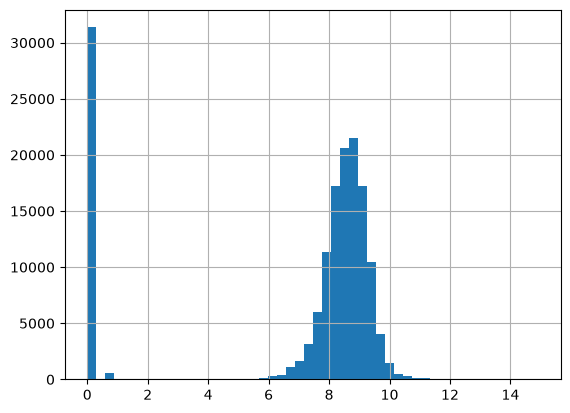

In [66]:
other_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
    "MonthlyIncome",
]

def target_by_qcut(df, col, q=5):
    s = df[col]
    bins = pd.qcut(s, q=q, duplicates="drop")
    return (
        df.assign(_bin=bins)
        .groupby("_bin", observed=True)[target]
        .agg(default_rate="mean", n="size")
    )

u = eda["RevolvingUtilizationOfUnsecuredLines"]
print(u.describe(percentiles=[0.5, 0.9, 0.99]))
print("util>1:", (u > 1).mean(), "util>10:", (u > 10).mean())

# income
eda.assign(log_income=np.log1p(eda["MonthlyIncome"].fillna(0)))["log_income"].hist(bins=50)

for c in ["NumberOfOpenCreditLinesAndLoans", "NumberRealEstateLoansOrLines"]:
    print("\n", c)
    display(target_by_qcut(eda, c))

print("\n", "NumberOfDependents")
(
    eda.assign(dep=eda["NumberOfDependents"].fillna(-1).clip(upper=5))
    .groupby("dep")[target]
    .agg(default_rate="mean", n="size")
)

### Correlations

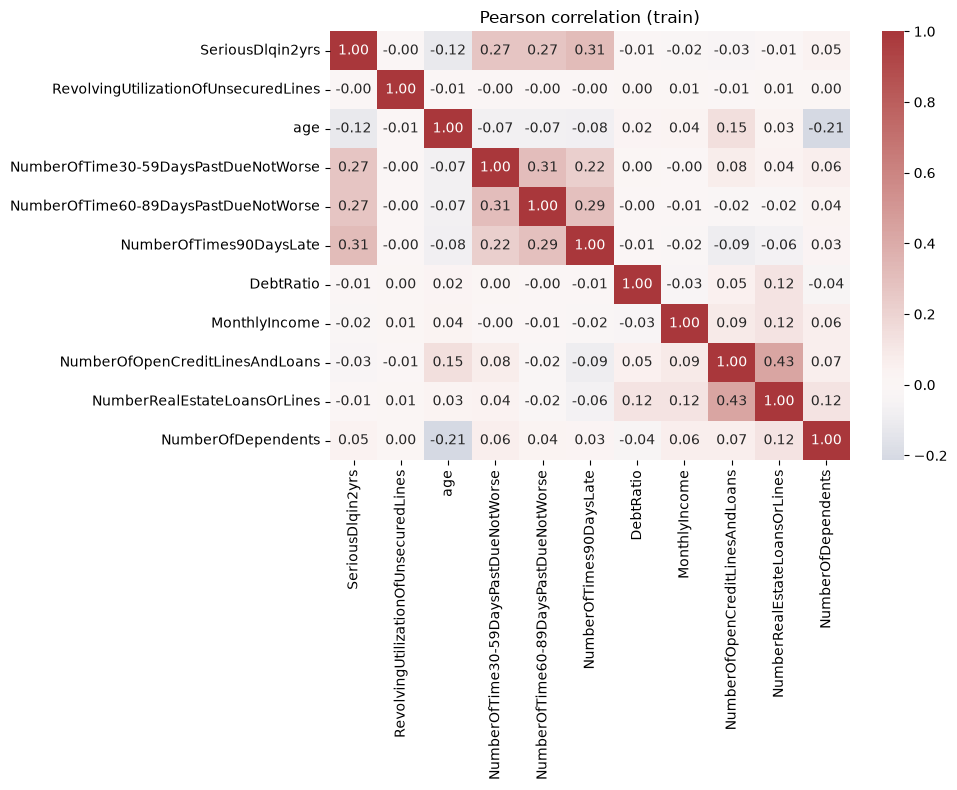

NumberOfTimes90DaysLate                 0.314535
NumberOfTime30-59DaysPastDueNotWorse    0.274550
NumberOfTime60-89DaysPastDueNotWorse    0.268130
age                                    -0.115386
NumberOfDependents                      0.046048
NumberOfOpenCreditLinesAndLoans        -0.029669
MonthlyIncome                          -0.019746
DebtRatio                              -0.007602
NumberRealEstateLoansOrLines           -0.007038
RevolvingUtilizationOfUnsecuredLines   -0.001802
Name: SeriousDlqin2yrs, dtype: float64

In [70]:
corr_df = eda.copy()

for c in delinq_cols:
    corr_df[c] = corr_df[c].replace({96: np.nan, 98: np.nan})

num_cols = [
    target,
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    *delinq_cols,
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
]

corr = corr_df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Pearson correlation (train)")
plt.tight_layout()
plt.show()


corr[target].drop(target).sort_values(key=abs, ascending=False)

# Decisions

* Dataset have ~600 duplicates, must be droped
* MonthlyIncome and NumberOfDependents have Missing Values with meaninfull differences, I'll follow with Median inputation + creating a missing indicator.
* The median inputation is more important for logreg than for tree based algo
* DebtRatio have values concentrated > 10 (clipped) when Monthly Income is Missing, for now none treatment will necessary as the missing flag will capture this, but some normalization will be performed
* Age seems ok, For values < 18 we have only 1 case, so it will be dropped; ages >100 I'll be capped to 100 the frequency is minimum so not great effects are expected.
* Deliquency columns seems normal. Sentinel values (96,98) not too frequent but default rate is very high. I'll map to Nans, Then input with the max(ex sentinels) + flag
* NumberOfOpenCreditLinesAndLoans split seems more relevant in the tails
* NumberRealEstateLoansOrLines split more relevant for (2.0, 54.0], outliers may be a data problem
* NumberOfDependents; -1(nan) dafault rate more close to 0, strategy will be impute with 0
* RevolvingUtilizationOfUnsecuredLines values are expected to be between (0,1), but the EDA showed a max value of 50708.0, problably a problem with denominator. Strategy will be clib values between 0 and 1 +  clreating a flag.

*Target has ~ 6.7% positives, imabalanced, but of for a credit problem. SMOTE/Oversampling will problably not be necessary. Main Metrics like ROC-AUC/Gini and KS should work fine for model selection.

### Correlations

* Age as expected has a negative correlation, this means that risk decrease when age increases
* Deliquency Cols have a positive correlation with target what is expected, correlation between them is ~ less than 30 fpr now its ok.
